In [22]:
# 데이터 처리를 위한 pandas 라이브러리
import pandas as pd

# 수치 연산 및 배열 조작을 위한 numpy 라이브러리
import numpy as np

# 이상치에 강건한 정규화를 위한 RobustScaler (중앙값과 IQR 기반 스케일링)
from sklearn.preprocessing import RobustScaler

# 로지스틱 회귀 모델 (이진 분류 모델)을 위한 클래스
from sklearn.linear_model import LogisticRegression

# 학습 데이터와 테스트 데이터를 나누기 위한 함수
from sklearn.model_selection import train_test_split

# 데이터 불균형 문제 해결을 위한 언더샘플링 기법 제공 (예: RandomUnderSampler)
from imblearn.under_sampling import *

# 통계 모델 분석 및 회귀 결과 요약 등을 위한 라이브러리
import statsmodels.api as sm

# 데이터 시각화를 위한 seaborn 라이브러리
import seaborn as sns

# 데이터 시각화를 위한 matplotlib 라이브러리 (기초 그래프 기능)
import matplotlib.pyplot as plt


In [23]:
# Kaggle에서 제공하는 심장병 관련 건강지표 데이터셋을 불러옴
# 파일 경로는 "/content/heart_2020_cleaned.csv" (Google Colab 환경 기준)
df = pd.read_csv("/content/heart_2020_cleaned.csv")

# 데이터셋의 상위 5개 행을 출력하여 데이터가 어떻게 구성되어 있는지 확인
df.head()


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [24]:
# 명목형 변수(범주형 변수)를 더미 변수(dummy variable, one-hot encoding)로 변환
# 예: 'Sex' 컬럼이 'Male', 'Female'이라면 → 'Sex_Male' (drop_first=True 옵션 때문에 하나만 생성)

# drop_first=True 옵션은 다중공선성(multicollinearity)을 줄이기 위해
# 각 범주형 변수에서 첫 번째 범주는 제거하고 나머지만 더미 변수로 생성함
df2 = pd.get_dummies(df, columns=[
    'HeartDisease',      # 심장 질환 여부
    'Smoking',           # 흡연 여부
    'AlcoholDrinking',   # 음주 여부
    'Stroke',            # 뇌졸중 경험 여부
    'DiffWalking',       # 보행 곤란 여부
    'Sex',               # 성별
    'AgeCategory',       # 연령대 (예: 18-24, 25-29 등)
    'Race',              # 인종
    'Diabetic',          # 당뇨병 여부
    'PhysicalActivity',  # 신체 활동 여부
    'GenHealth',         # 일반적인 건강 상태 (Excellent, Good 등)
    'Asthma',            # 천식 여부
    'KidneyDisease',     # 신장 질환 여부
    'SkinCancer'         # 피부암 여부
], drop_first=True)

# 변환된 데이터프레임의 상위 5개 행을 확인
df2.head()


,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,16.60,3.0,30.0,5.0,False,True,False,False,False,False,...,True,False,True,False,False,False,True,True,False,True
1,20.34,0.0,0.0,7.0,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
2,26.58,20.0,30.0,8.0,False,True,False,False,False,True,...,True,False,True,True,False,False,False,True,False,False
3,24.21,0.0,0.0,6.0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,23.71,28.0,0.0,8.0,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False


In [25]:
# RobustScaler 적용을 위한 준비

# 숫자형 변수만 따로 추출 (BMI, 신체 건강, 정신 건강, 수면 시간)
df_num = df[['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']]

# df2에서 숫자형 변수들을 제외한 더미 처리된 명목형 변수만 분리
df_nom = df2.drop(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], axis=1)

# RobustScaler는 이상치에 덜 민감한 스케일링 방법 (중앙값과 IQR 기반)
# RobustScaler 객체 생성 후 숫자형 변수에 대해 스케일링 수행
RobustScaler = RobustScaler()
df_robust = RobustScaler.fit_transform(df_num)

# 스케일링된 결과는 numpy 배열이므로, 다시 원래의 컬럼명을 갖는 DataFrame으로 변환
df_num2 = pd.DataFrame(data=df_robust, columns=df_num.columns)

# 스케일링된 숫자형 데이터(df_num2)와 더미 처리된 명목형 데이터(df_nom)를 열 방향으로 합침
df3 = pd.concat([df_num2, df_nom], axis=1)

# 최종 결합된 데이터프레임의 상위 5개 행 확인
df3.head()


,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,-1.453315,1.5,10.0,-1.0,False,True,False,False,False,False,...,True,False,True,False,False,False,True,True,False,True
1,-0.947226,0.0,0.0,0.0,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
2,-0.102842,10.0,10.0,0.5,False,True,False,False,False,True,...,True,False,True,True,False,False,False,True,False,False
3,-0.423545,0.0,0.0,-0.5,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,-0.491204,14.0,0.0,0.5,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False


In [26]:
# 종속변수(HeartDisease_Yes)와 독립변수 분리

# 'HeartDisease_Yes'는 심장질환 여부(Yes/No 중 Yes에 해당하는 더미 변수)
# 해당 컬럼을 종속변수로 설정하고, 나머지를 독립변수로 설정
X = df3.drop(['HeartDisease_Yes'], axis=1)  # 입력 변수 (features)
y = df3[['HeartDisease_Yes']]              # 출력 변수 (target)

# 학습셋과 테스트셋을 75:25 비율로 분할
# random_state를 고정하여 실행할 때마다 동일한 결과가 나오도록 설정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10)

# 각 데이터셋의 크기를 출력하여 분할이 잘 되었는지 확인
print('train data 개수: ', len(X_train))
print('test data 개수: ', len(X_test))


train data 개수:  239846
test data 개수:  79949


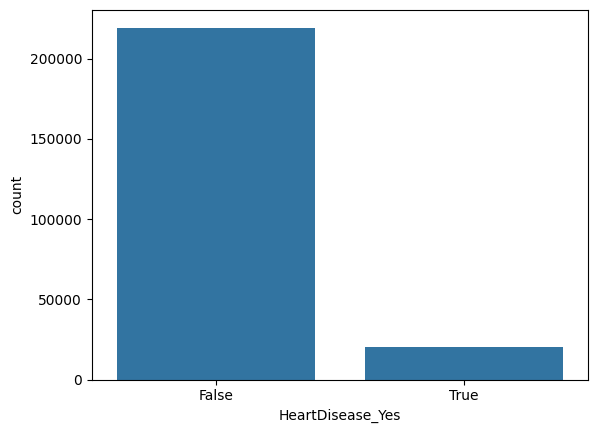

In [27]:
# 종속변수(HeartDisease_Yes)의 학습 데이터에서 클래스 분포를 시각화
# 클래스가 불균형한지 여부를 확인하는 데 유용함

sns.countplot(x="HeartDisease_Yes", data=y_train)

# 그래프를 출력
plt.show()


In [28]:
# 학습 데이터를 복사하여 임시 변수명 적용할 새로운 DataFrame 생성
X_train_re = X_train.copy()
y_train_re = y_train.copy()

# 임시 변수명을 리스트로 정의
# 총 37개의 입력 변수에 대해 X1 ~ X37로 컬럼명 변경
X_temp_name = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
               'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20',
               'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30',
               'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37']

# 종속 변수는 하나이므로 y1로 이름 지정
y_temp_name = ['y1']

# 컬럼명을 임시 변수명으로 변경
X_train_re.columns = X_temp_name
y_train_re.columns = y_temp_name

# 변경된 학습 입력 데이터의 상위 5개 행 출력
X_train_re.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37
163572,-0.202977,0.0,0.0,-0.5,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
150901,1.476319,0.0,0.0,0.5,True,False,True,False,True,False,...,False,False,True,False,False,False,True,False,False,False
164527,-0.248985,15.0,10.0,-2.0,True,False,False,True,True,False,...,False,False,True,False,False,True,False,False,False,False
260971,0.805142,0.0,0.0,0.0,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,False
262287,0.612991,5.0,0.0,0.0,False,False,False,False,True,False,...,True,False,True,False,True,False,False,False,False,False


In [29]:
# 학습 데이터에 언더샘플링(RandomUnderSampler) 적용
# 과소대표된 클래스의 수에 맞춰 다수 클래스를 무작위로 줄임
# 클래스 불균형 문제를 완화하고자 사용됨

X_train_under, y_train_under = RandomUnderSampler(
    random_state=0  # 결과 재현성을 위한 시드 설정
).fit_resample(X_train_re, y_train_re)

# 언더샘플링 전의 학습 변수/레이블 크기 출력
print('RandomUnderSampler 적용 전 학습셋 변수/레이블 데이터 세트: ',
      X_train_re.shape, y_train_re.shape)

# 언더샘플링 후의 학습 변수/레이블 크기 출력
print('RandomUnderSampler 적용 후 학습셋 변수/레이블 데이터 세트: ',
      X_train_under.shape, y_train_under.shape)

# 언더샘플링 전 레이블(y1)의 클래스 분포 확인
print('RandomUnderSampler 적용 전 레이블 값 분포: \n',
      pd.Series(y_train_re['y1']).value_counts())

# 언더샘플링 후 레이블(y1)의 클래스 분포 확인
print('RandomUnderSampler 적용 후 레이블 값 분포: \n',
      pd.Series(y_train_under['y1']).value_counts())


RandomUnderSampler 적용 전 학습셋 변수/레이블 데이터 세트:  (239846, 37) (239846, 1)
RandomUnderSampler 적용 후 학습셋 변수/레이블 데이터 세트:  (41036, 37) (41036, 1)
RandomUnderSampler 적용 전 레이블 값 분포: 
 y1
False    219328
True      20518
Name: count, dtype: int64
RandomUnderSampler 적용 후 레이블 값 분포: 
 y1
False    20518
True     20518
Name: count, dtype: int64


In [30]:
# 언더샘플링된 학습 데이터(X_train_under, y_train_under)의 컬럼명을
# 원래의 학습 데이터(X_train, y_train)의 컬럼명으로 복구

X_train_under.columns = list(X_train)  # 원래 feature 컬럼명 복구
y_train_under.columns = list(y_train)  # 원래 target 컬럼명 복구

# 컬럼명이 복구된 X_train_under의 상위 5개 행 확인
X_train_under.head()


,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,AgeCategory_25-29,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
69819,-0.572395,0.0,1.666667,0.5,False,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False
248332,2.365359,6.0,0.333333,-0.5,False,False,False,False,False,False,...,True,False,True,True,False,False,False,False,False,False
31381,-0.964817,0.0,2.666667,0.5,False,False,False,False,True,False,...,False,False,True,False,False,False,True,True,False,False
152264,-1.246279,0.0,0.000000,-0.5,True,False,False,True,True,False,...,False,False,True,False,True,False,False,True,False,False
90674,0.668471,15.0,0.000000,0.5,True,False,False,False,True,False,...,True,False,True,True,False,False,False,False,False,False


In [31]:
# 로지스틱 회귀 모델 생성 (기본 설정 사용)
model = LogisticRegression()

# 언더샘플링된 학습 데이터를 사용하여 모델 학습 수행
model.fit(X_train_under, y_train_under)

# 학습된 모델을 학습셋에 대해 평가하고 정확도 출력
print('학습셋 모델 정확도:', model.score(X_train_under, y_train_under))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


학습셋 모델 정확도: 0.7646700458134321


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
# 테스트셋을 이용해 학습된 로지스틱 회귀 모델의 정확도 평가
# 모델이 보지 못한 데이터에 대해 얼마나 잘 예측하는지 확인

print('테스트셋 모델 정확도:', model.score(X_test, y_test))


테스트셋 모델 정확도: 0.7501657306532915


In [33]:
# 학습된 로지스틱 회귀 모델의 회귀 계수(coefficient) 확인
# 각 특성(독립변수)이 종속변수(심장질환 여부)에 미치는 영향의 크기와 방향을 나타냄

print(model.coef_)


[[ 8.03756661e-02  1.18969410e-02  2.93419123e-02 -5.48205154e-02
   4.06067693e-01 -2.46473690e-01  1.28120913e+00  2.00117743e-01
   7.59656656e-01 -5.76677878e-02  3.97929058e-01  4.15806607e-01
   7.86812373e-01  1.07631787e+00  1.52820461e+00  1.76609080e+00
   2.04635302e+00  2.33241052e+00  2.68444710e+00  2.84136002e+00
   3.20268262e+00 -5.28894643e-01 -2.43361104e-01 -1.83563644e-01
  -9.69185583e-02 -5.97598910e-02  2.81329164e-01  4.80037238e-01
   4.37328675e-01 -1.77842388e-03  1.49888030e+00  1.02722560e+00
   1.81032858e+00  4.45384525e-01  2.95023154e-01  6.17040093e-01
   1.41288252e-01]]


In [34]:
# statsmodels의 Logit 클래스를 사용하여 로지스틱 회귀 모델 학습

# X_train_under와 y_train_under가 object 타입을 가질 경우 오류가 발생할 수 있으므로
# float 타입으로 명시적으로 변환 (모든 값이 수치형임을 보장)
X_train_under = X_train_under.astype(float)
y_train_under = y_train_under.astype(float)

# 로지스틱 회귀 모델 생성 (종속변수: y_train_under, 독립변수: X_train_under)
model2 = sm.Logit(y_train_under, X_train_under)

# 모델 학습 (최적화 알고리즘으로 'newton' 방식 사용)
results = model2.fit(method="newton")

# 회귀 결과 요약 출력 (계수, 표준오차, p값, Pseudo R² 등 포함)
results.summary()


Optimization terminated successfully.
         Current function value: 0.503919
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       HeartDisease_Yes   No. Observations:                41036
Model:                          Logit   Df Residuals:                    40999
Method:                           MLE   Df Model:                           36
Date:                Tue, 13 May 2025   Pseudo R-squ.:                  0.2730
Time:                        10:07:25   Log-Likelihood:                -20679.
converged:                       True   LL-Null:                       -28444.
Covariance Type:            nonrobust   LLR p-value:                     0.000
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
BMI                                  0.0918      0.015      6.056      0.000       0.062       0.121
PhysicalHealth                       0.0114      0.003      3.367      0.001       0.005       0.018
MentalHealth                         0.0170      0.005      3.478      0.001       0.007       0.027
SleepTime                           -0.0733      0.016     -4.619      0.000      -0.104      -0.042
Smoking_Yes                          0.3696      0.025     14.807      0.000       0.321       0.419
AlcoholDrinking_Yes                 -0.2732      0.053     -5.107      0.000      -0.378      -0.168
Stroke_Yes                           1.2616      0.054     23.555      0.000       1.157       1.367
DiffWalking_Yes                      0.1708      0.035      4.907      0.000       0.103       0.239
Sex_Male                             0.6680      0.025     26.580      0.000       0.619       0.717
AgeCategory_25-29                   -1.4044      0.127    -11.088      0.000      -1.653      -1.156
AgeCategory_30-34                   -0.9200      0.103     -8.905      0.000      -1.122      -0.717
AgeCategory_35-39                   -0.9326      0.097     -9.634      0.000      -1.122      -0.743
AgeCategory_40-44                   -0.5486      0.089     -6.190      0.000      -0.722      -0.375
AgeCategory_45-49                   -0.2661      0.082     -3.244      0.001      -0.427      -0.105
AgeCategory_50-54                    0.1993      0.076      2.636      0.008       0.051       0.348
AgeCategory_55-59                    0.4354      0.072      6.049      0.000       0.294       0.576
AgeCategory_60-64                    0.7295      0.070     10.414      0.000       0.592       0.867
AgeCategory_65-69                    1.0211      0.070     14.680      0.000       0.885       1.157
AgeCategory_70-74                    1.3695      0.070     19.549      0.000       1.232       1.507
AgeCategory_75-79                    1.5302      0.073     20.958      0.000       1.387       1.673
AgeCategory_80 or older              1.8668      0.072     25.936      0.000       1.726       2.008
Race_Asian                          -2.6688      0.120    -22.307      0.000      -2.903      -2.434
Race_Black                          -2.3371      0.081    -28.721      0.000      -2.497      -2.178
Race_Hispanic                       -2.3334      0.080    -29.136      0.000      -2.490      -2.176
Race_Other                          -2.2070      0.093    -23.681      0.000      -2.390      -2.024
Race_White                          -2.1554      0.069    -31.379      0.000      -2.290      -2.021
Diabetic_No, borderline diabetes     0.2903      0.078      3.734      0.000       0.138       0.443
Diabetic_Yes                         0.4801      0.032     14.907      0.000       0.417       0.543
Diabetic_Yes (during pregnancy)      0.2256      0.164      1.376      0.169      -0.096       0.547
PhysicalA

In [35]:
# 로지스틱 회귀 결과의 계수는 로그 오즈(log odds) 단위이므로
# 이를 지수 변환하여 오즈비(Odds Ratio)로 해석 가능하게 변환

np.exp(results.params)


,0
BMI,1.096091
PhysicalHealth,1.011469
MentalHealth,1.017101
SleepTime,0.929300
Smoking_Yes,1.447148
AlcoholDrinking_Yes,0.760970
Stroke_Yes,3.530911
DiffWalking_Yes,1.186292
Sex_Male,1.950422
AgeCategory_25-29,0.245524
